# Cells for running the package simulations in order to check its results

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from scipy.integrate import solve_ivp
from solve_dae.integrate import solve_dae
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent / "src")) # Source code
from benchmark_systems.models import (
    dc_motor,
    pendulum,
    cart_pendulum,
    multimass_spring,
    double_cart_pendulum,
    multilevel_cart_pendulum,
    cstr,
    batch_bioreactor,
    johansson,
    oil_well,
    neutralization
)
from benchmark_systems.symbolic import (
    quadrotor_ode,
    solve_ivp_casadi
)
from benchmark_systems.animations import (
    AutoAnimation,
    DCMotor,
    Pendulum,
    CartPendulum,
    MultimassSpring,
    MultiCartPendulum,
    Quadrotor,
    CSTR,
    BatchBioreactor,
    JohanssonTanks,
    OilWell,
    pHNeutralization
)

import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.figsize': (12, 6)})

### DC-Motor

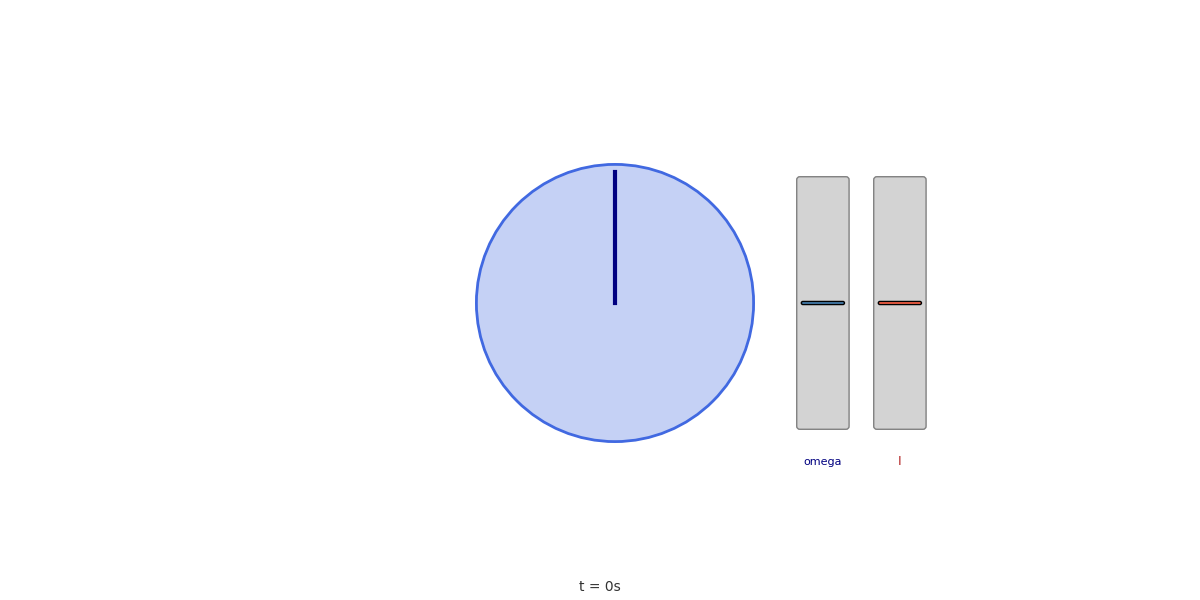

In [3]:
dcmotor_states = solve_ivp(lambda t, x: dc_motor(t, x, R=1, L=0.5, Kt=0.01, Ke=0.01, J=0.02, b=0.1, u=1),
                            t_span=(0, 10), y0=[0, 0, 0], t_eval=np.linspace(0, 10, 1000), rtol=1e-6)

%matplotlib ipympl
if 'dcmotor' in globals():
    plt.close('dcmotor')

fig, axis = plt.figure('dcmotor'), plt.gca()
anim, _ = AutoAnimation(fig, DCMotor(axis, theta=dcmotor_states.y[0], omega=dcmotor_states.y[1], current=dcmotor_states.y[2]),
                    duration=dcmotor_states.t[-1], dt=round(dcmotor_states.t[-1] - dcmotor_states.t[-2],3))

### Simple pendulum

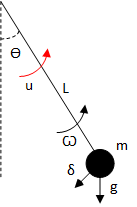

States: $x = \begin{bmatrix} \theta \\ \omega \end{bmatrix}$; Control actions: $u$

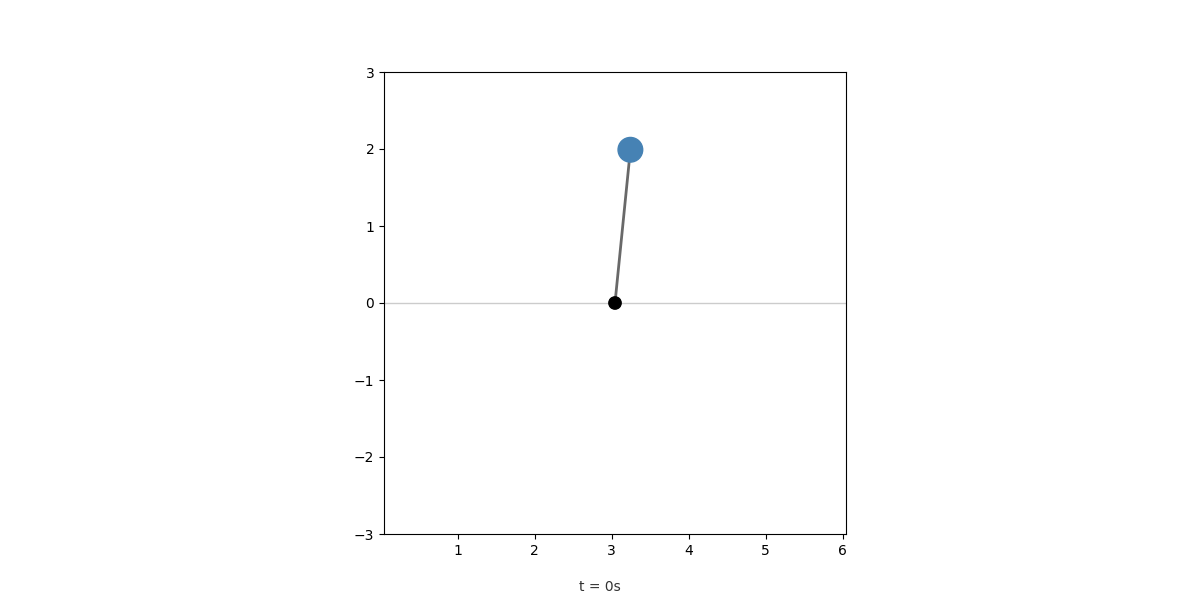

In [10]:
pendulum_states = solve_ivp(lambda t, x: pendulum(t, x, m=1, L=2, drag=0, u=0),
                            t_span=(0, 20), y0=[np.pi-0.1, 0], t_eval=np.linspace(0, 20, 1000), rtol=1e-6)

%matplotlib ipympl
if 'pendulum' in globals():
    plt.close('pendulum')
fig, axis = plt.figure('pendulum'), plt.gca()
anim, _ = AutoAnimation(fig, Pendulum(axis, L=2, theta=pendulum_states.y[0], pivot=(np.pi-0.1, 0)),
                    duration=pendulum_states.t[-1], dt=round(pendulum_states.t[-1] - pendulum_states.t[-2],3), time_fmt='.2f')

### Cart-Pendulum

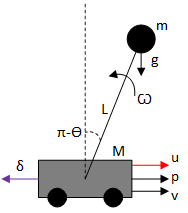

States: $x = \begin{bmatrix} p \\ v \\ \theta \\ \omega \end{bmatrix}$; Control actions: $u$

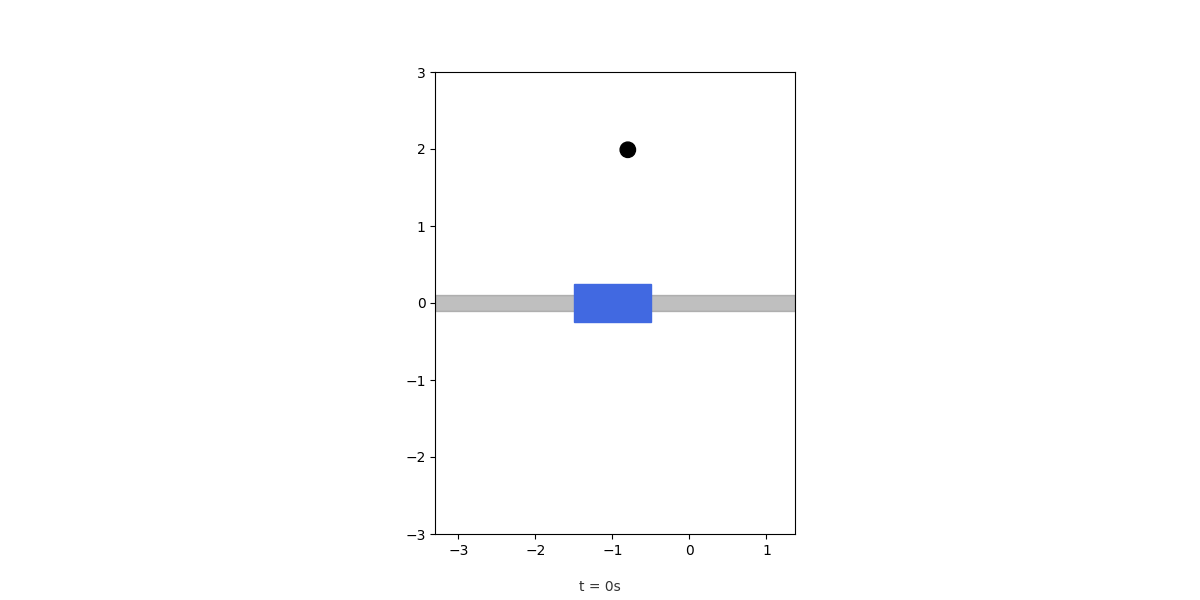

In [11]:
cp_states = solve_ivp(lambda t, x: cart_pendulum(t, x, m=1, M=5, L=2, drag=0, u=0),
                            t_span=(0, 20), y0=[-1, 0, np.pi-0.1, 0], t_eval=np.linspace(0, 20, 1000), rtol=1e-6)


%matplotlib ipympl
if 'cart_pendulum' in globals():
    plt.close('cart_pendulum')
fig, axis = plt.figure('cart_pendulum'), plt.gca()
anim, _ = AutoAnimation(fig, CartPendulum(axis, L=2, pos=cp_states.y[0], theta=cp_states.y[2]),
                    duration=cp_states.t[-1], dt=round(cp_states.t[-1] - cp_states.t[-2],3), time_fmt='.2f')

### Double Inverted Pendulum

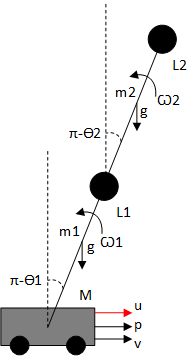

States: $x = \begin{bmatrix} p \\ \theta_1 \\ \theta_2 \\ v \\ \omega_1 \\ \omega_2 \end{bmatrix}$; Control actions: $u$

In [ ]:
dip_states = solve_dae(lambda t, x, z: double_cart_pendulum(t, x, z, M=0.6, m1=0.2, m2=0.2, L1=0.5, L2=0.5, u=0),
                       t_span=(0, 20), y0=[0, 0, np.pi-0.1, 0, 0, 0], yp0=np.zeros(6), t_eval=np.linspace(0, 20, 1000), rtol=1e-6)

%matplotlib ipympl
if 'double_cart_pendulum' in globals():
    plt.close('double_cart_pendulum')
fig, axis = plt.figure('double_cart_pendulum'), plt.gca()
anim, _ = AutoAnimation(fig, MultiCartPendulum(axis, L=[0.5, 0.5], pos=dip_states.y[0], thetas=dip_states.y[1:3]),
                    duration=dip_states.t[-1], dt=round(dip_states.t[-1] - dip_states.t[-2],3), time_fmt='.2f')

c:\Users\Automatica\anaconda3\envs\pdm\Lib\site-packages\matplotlib\animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


### Triple Inverted Pendulum

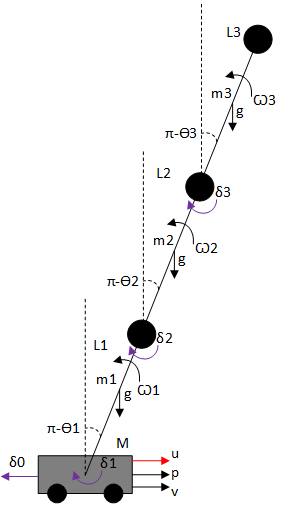

States: $x = \begin{bmatrix} p \\ \theta_1 \\ \theta_2 \\ \theta_3 \\ v \\ \omega_1 \\ \omega_2 \\ \omega_3 \end{bmatrix}$; Control actions: $u$

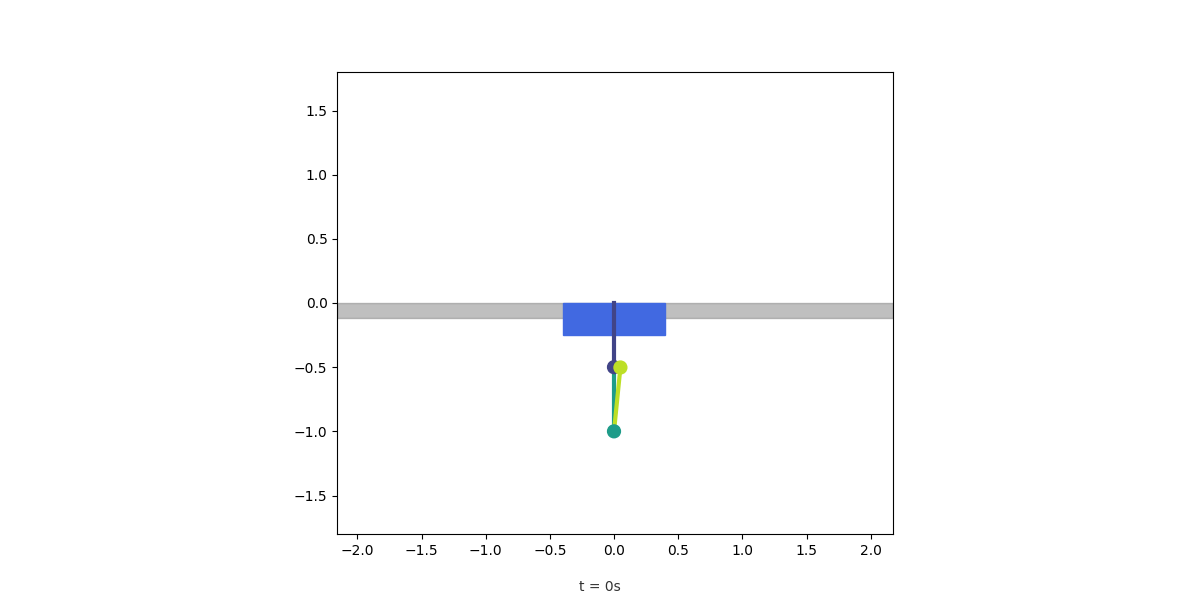

In [ ]:
tip_states = solve_dae(lambda t, x, z: multilevel_cart_pendulum(t, x, z, M=0.6, m=[0.2]*3, L=[0.5]*3, u=0),
                       t_span=(0, 20), y0=[0, 0, 0, np.pi-0.1, 0, 0, 0, 0], yp0=np.zeros(8), t_eval=np.linspace(0, 20, 1000), rtol=1e-6)

%matplotlib ipympl
if 'triple_cart_pendulum' in globals():
    plt.close('triple_cart_pendulum')
fig, axis = plt.figure('triple_cart_pendulum'), plt.gca()
anim, _ = AutoAnimation(fig, MultiCartPendulum(axis, L=[0.5, 0.5, 0.5], pos=tip_states.y[0], thetas=tip_states.y[1:4]),
                    duration=tip_states.t[-1], dt=round(tip_states.t[-1] - tip_states.t[-2],3), time_fmt='.2f')

### Multimass Spring System

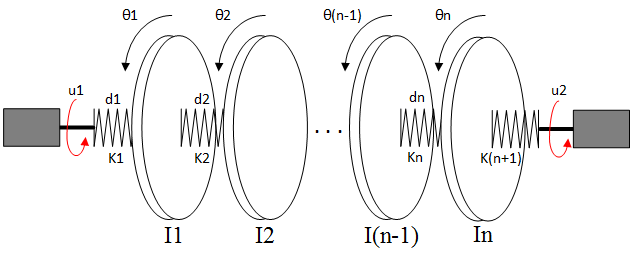

States: $x = \begin{bmatrix} u^{true}_1 \\ u^{true}_2 \\ \theta_1 \\ \theta_2 \\ \dots \\ \theta_n \\
\dot{\theta}_1 \\ \dot{\theta}_2 \\ \dots \\ \dot{\theta}_n \end{bmatrix}$; Control actions: $u = \begin{bmatrix} u_1 \\ u_2 \end{bmatrix}$

In [4]:
multimass_params = {
    'tau': [1e-2]*2, # Time constants of the stepper motors
    'I': [2.25*1e-4]*3, # Inertia of each mass
    'K': np.array([2.697,  2.66,  3.05, 2.86])*1e-3, # Spring constants
    'd': np.array([6.78,  8.01,  8.82])*1e-5, # Damping constants
}

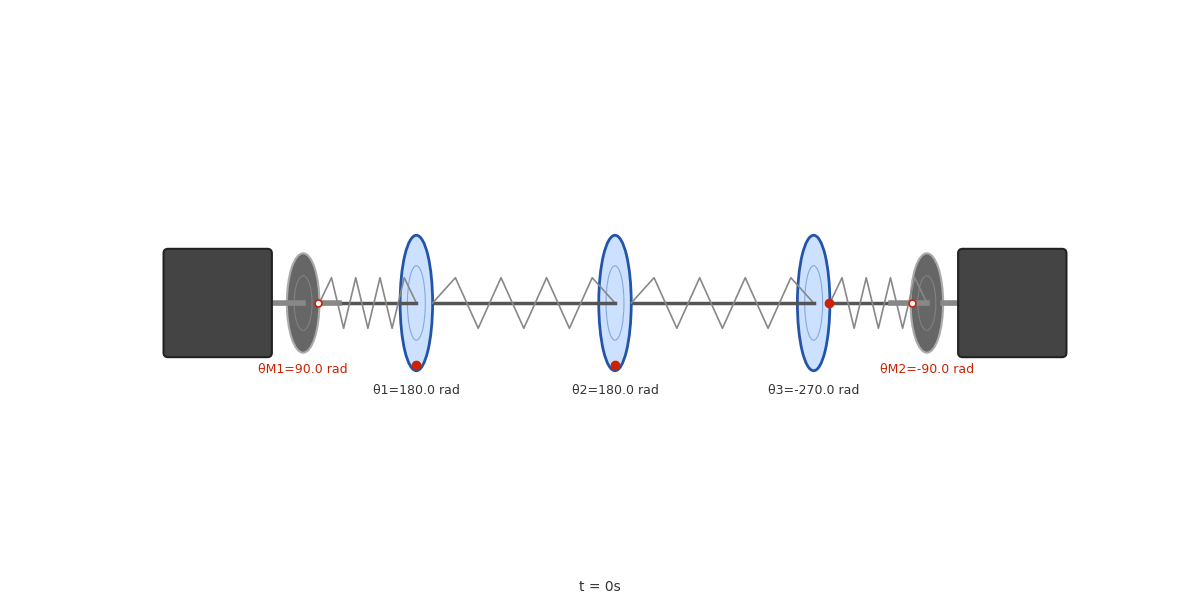

In [5]:
damper_states = solve_ivp(lambda t, x: multimass_spring(t, x, **multimass_params, u=[0,0]),
                            t_span=(0, 20), y0=np.pi*np.array([0.5, -0.5, 1, 1, -1.5, 1, -1, 1]), t_eval=np.linspace(0, 20, 1000))

%matplotlib ipympl
if 'multimass_spring' in globals():
    plt.close('multimass_spring')
fig, axis = plt.figure('multimass_spring'), plt.gca()
anim, _ = AutoAnimation(fig, MultimassSpring(axis, K=multimass_params['K'], u_true=damper_states.y[0:2], thetas=damper_states.y[2:5]),
                    duration=damper_states.t[-1], dt=round(damper_states.t[-1] - damper_states.t[-2],3))

### Johansson's 4 tank system

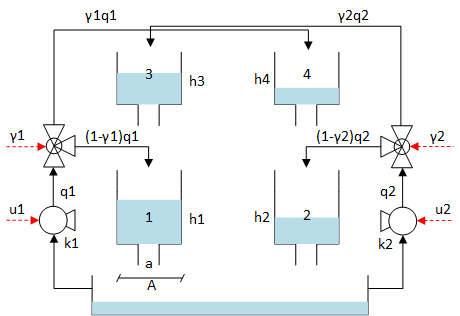

States: $x = \begin{bmatrix} h_1 \\ h_2 \\ h_3 \\ h_4 \end{bmatrix}$; Control actions: $u = \begin{bmatrix} u_1 \\ u_2 \end{bmatrix}$

In [6]:
johansson_params = {
    'h_max': [25, 25, 20, 20], # cm
    'A' : [389.16] * 4, #cm^2
    'a': [((1.4/2) ** 2) * np.pi] * 4, # cm^2
    'K' : [6.74, 7.94],
    'gamma': [0.7, 0.6] # Non-minimum phase configuration
}

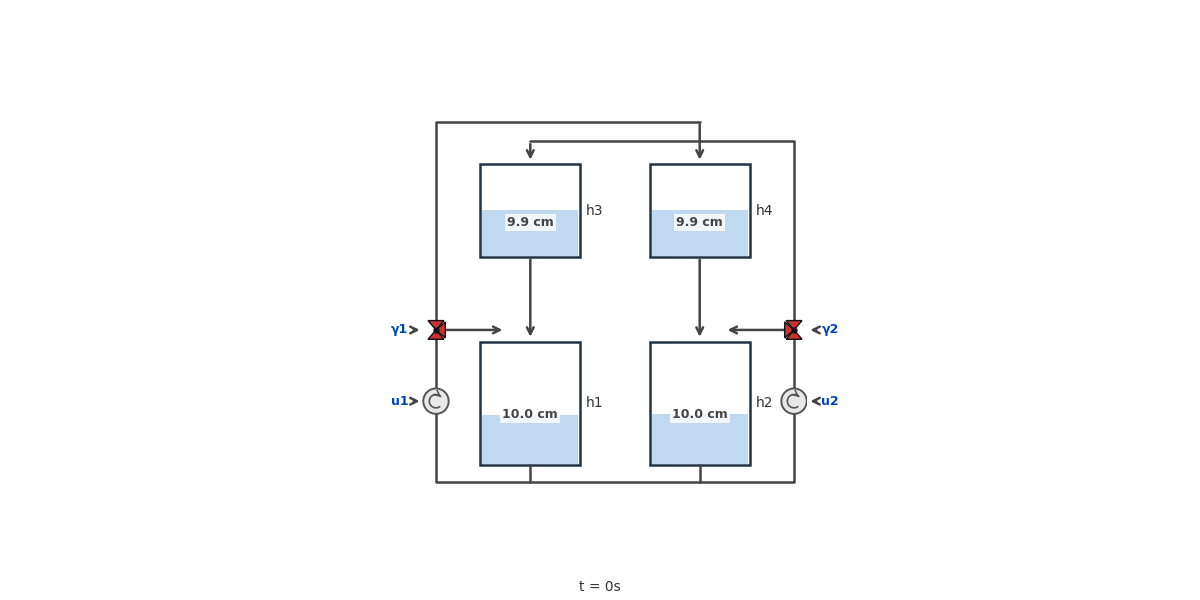

In [30]:
duration = 30 # seconds
Ts = 0.3 # seconds

# 20 random setpoints (0-100) for pump 1 and 2.
rangen = np.random.default_rng(seed=44)
u1, u2 = [rangen.random(20)*100 for _ in range(2)]

# Simulation of the system ... Every setpoint is held for 30 seconds
johansson_states = np.array([[] for _ in range(4)])
for u1_k, u2_k in zip(u1, u2):
    # Solve the system for 30 seconds, taking 100 samples in that interval
    heights = solve_ivp(lambda t, x: johansson(t, x, u=[u1_k, u2_k], **johansson_params),
                            y0 = [10, 10, 10, 10] if johansson_states.size == 0 else johansson_states[:, -1],
                            t_span=(0, duration), t_eval=np.linspace(Ts, duration, int(duration/Ts)), rtol=1e-6)
    # Append the states
    johansson_states = np.hstack([johansson_states, heights.y])

%matplotlib ipympl
if 'johansson' in globals():
    plt.close('johansson')
fig, axis = plt.figure('johansson'), plt.gca()
anim, _ = AutoAnimation(fig, JohanssonTanks(axis, h_max=johansson_params['h_max'], heights=johansson_states,
                                            pumps=[np.repeat(u1, int(duration/Ts)), np.repeat(u2, int(duration/Ts))],
                                            gammas=[np.repeat(johansson_params['gamma'][0], int((len(u1)*duration/Ts))),
                                                    np.repeat(johansson_params['gamma'][1], int((len(u2)*duration/Ts)))]),
                        duration=duration*len(u1), dt=Ts, speed=5)

### Batch Bioreactor

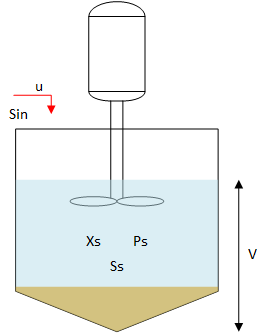

States: $x = \begin{bmatrix} X_s \\ S_s \\ P_s \\ V \end{bmatrix}$; Control actions: $u$

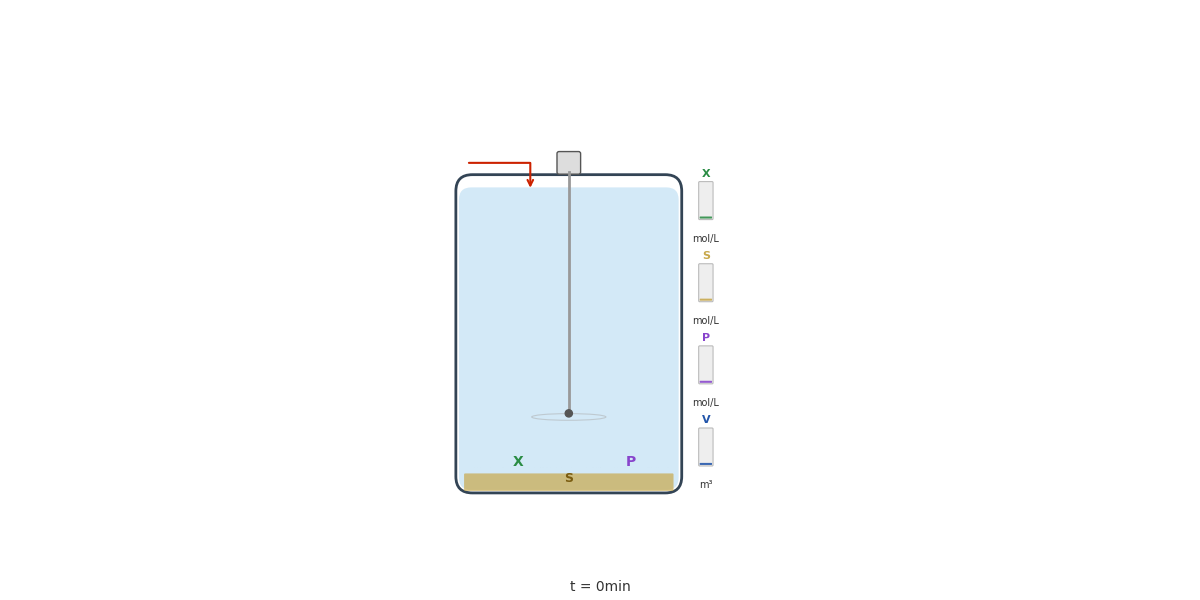

In [8]:
duration = 1 # minutes
Ts = 0.01 # minutes

# Feed flow rate between 0 and 0.1.
k = np.arange(0, duration, Ts)
u = 0.05*(1 + np.sin(2*np.pi*k - np.pi))

# Simulation of the batch reactor ... Every setpoint is held for 1 minute
batch_states = np.array([[] for _ in range(4)])
for u_k in u:
    # Solve the system for 1 minute, taking 100 samples in that interval
    states = solve_ivp(lambda t, x: batch_bioreactor(t, x, S_in=200, mu_max=0.02, K_m=0.05, K_i=5, v=0.04, Y_x=0.5, Y_p=1.2, u=u_k),
                       y0 = [1, 0.5, 0, 120] if batch_states.size == 0 else batch_states[:, -1],
                       t_span=(0, duration), t_eval=np.linspace(Ts, duration, int(duration/Ts)))
    # Append the states
    batch_states = np.hstack([batch_states, states.y])

%matplotlib ipympl
if 'batch_bioreactor' in globals():
    plt.close('batch_bioreactor')
fig, axis = plt.figure('batch_bioreactor'), plt.gca()
anim, _ = AutoAnimation(fig, BatchBioreactor(axis, X=batch_states[0], S=batch_states[1], P=batch_states[2], V=batch_states[3], S_in=np.repeat(200, batch_states.shape[1]), u=np.repeat(u, int(duration/Ts))),
                        duration=duration*len(u), dt=Ts, time_unit='min')

### Continuous Stirred Tank Reactor (CSTR)

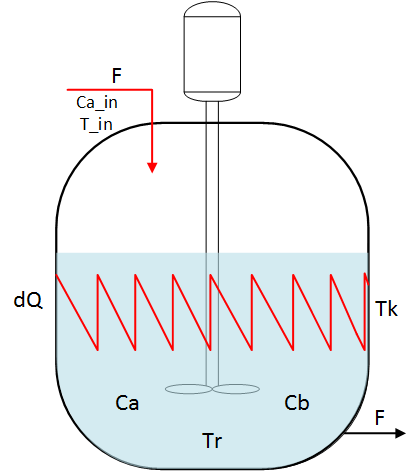

States: $x = \begin{bmatrix} C_a \\ C_b \\ T_r \\ T_k \end{bmatrix}$; Control actions: $u = \begin{bmatrix} F \\ \dot{Q} \end{bmatrix}$

In [21]:
arrhenius_eqs = {
    'K0_ab': 1.287e12, 'Ea_ab': 81.135, 'Hr_ab': 4.2, 
    'K0_bc': 1.287e12, 'Ea_bc': 81.135, 'Hr_bc': -11,
    'K0_ad': 9.043e9, 'Ea_ad': 71.172, 'Hr_ad': -41.85
}
reactor = {
    'rho': 0.9342, 'Cp': 3.01,
    'A': 0.215, 'V': 10, 'K_w': 4032
}
in_flow = {
    'Ca_in': 5.1, 'T_in': 130
}
coolant = {
    'Cp_k': 2, 'm_k': 5
}

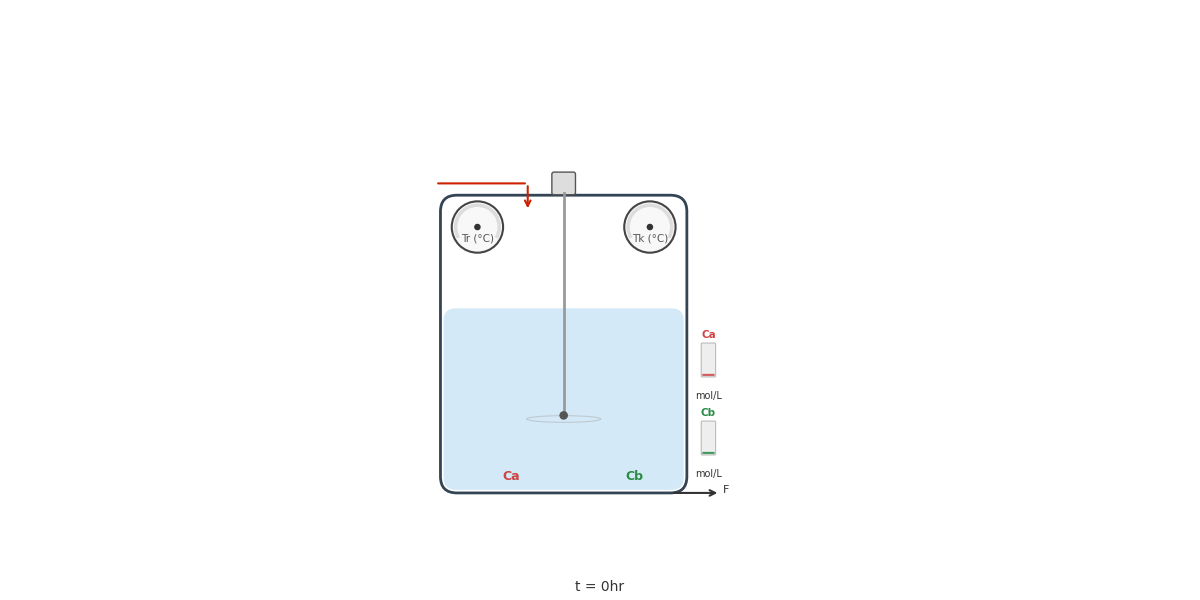

In [29]:
duration = 0.2 # hours
step_duration = 0.01 # hours
Ts = 0.0001 # hours

# Feed flow and heat flow
k = np.arange(0, duration, step_duration)
F = np.ones_like(k) * 10
dQ = -20000 * k
u = np.array([F, dQ]).T

# Simulation of the CSTR ... Every setpoint is held for 0.01 hours
cstr_states = np.array([[] for _ in range(4)])
for F_k, dQ_k in u:
    # Solve the system for 0.01 hours, taking 100 samples in that interval
    states = solve_ivp(lambda t, x: cstr(t, x, **arrhenius_eqs, **reactor, **in_flow, **coolant,
                                         u=[F_k, dQ_k]),
                       y0 = [0.8, 0.5, 134.14, 130] if cstr_states.size == 0 else cstr_states[:, -1],
                       t_span=(0, step_duration), t_eval=np.linspace(Ts, step_duration, int(step_duration/Ts)))
    # Append the states
    cstr_states = np.hstack([cstr_states, states.y])

%matplotlib ipympl
if 'cstr' in globals():
    plt.close('cstr')
fig, axis = plt.figure('cstr'), plt.gca()
anim, _ = AutoAnimation(fig, CSTR(axis, Ca=cstr_states[0], Cb=cstr_states[1], Tr=cstr_states[2], Tk=cstr_states[3],
                                  dQ=np.repeat(dQ, int(step_duration/Ts)), F=np.repeat(F, int(step_duration/Ts)),
                                  T_in=np.repeat(in_flow['T_in'], cstr_states.shape[1]), Ca_in=np.repeat(in_flow['Ca_in'], cstr_states.shape[1]),
                                  dQ_max_abs=np.max(np.abs(dQ)), Tr_min=np.min(cstr_states[2]), Tr_max=np.max(cstr_states[2]), Tk_min=np.min(cstr_states[3]), Tk_max=np.max(cstr_states[3])),
                        duration=duration, dt=Ts, time_fmt='.4f', time_unit='hr')

### Quadrotor

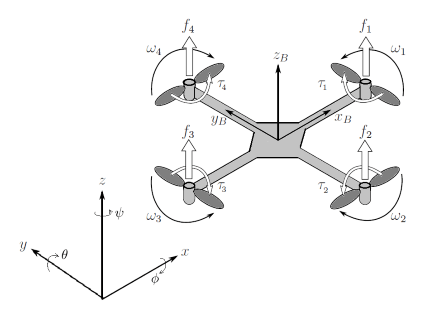

###### Image source: https://es.mathworks.com/help/symbolic/derive-quadrotor-dynamics-for-nonlinearMPC.html

* Newton-Euler model (ODE)
    States: $x = \begin{bmatrix} x \ y \ z \ \phi \ \theta \ \psi \ s \ v \ w \ p \ q \ r \end{bmatrix}^T$; 

* Euler-Lagrange model (DAE)
    States: $x = \begin{bmatrix} x \ y \ z \ \phi \ \theta \ \psi \ \dot{x} \ \dot{y} \ \dot{z} \ \dot{\phi} \ \dot{\theta} \ \dot{\psi} \end{bmatrix}^T$;

Control actions: $u = \begin{bmatrix} \omega_1^2 \ \omega_2^2 \ \omega_3^2 \ \omega_4^2 \end{bmatrix}^T$

In [3]:
quadrotor_params = {
    'Ixx': 1.2, 'Iyy': 1.2, 'Izz': 2.3, 'k': 1, 'L': 0.25, 'm': 2, 'drag': 0.2
}
w2 = quadrotor_params['m']*9.81/(quadrotor_params['k']*4) # Squared speed of the propellers in order to hover ... 4*k*w^2 = m*g
u = 4*[w2] # Hover

Get the nonlinear dynamics as a CasADi function:

In [4]:
quadrotor_fn = quadrotor_ode(**quadrotor_params)
quadrotor_fn

Function(quadrotor:(t,x[12],u[4])->(dx[12]) SXFunction)

Linearize the dynamics around the hover equilibrium point:

In [5]:
jac_quadrotor = quadrotor_fn.jacobian()(t=0.0, x=[0, 0, 5] + 9*[0], u=u)
A = jac_quadrotor['jac_dx_x']
B = jac_quadrotor['jac_dx_u']

Compute the LQR controller for the linearized system, using only the first 6 states (position and angles) in the cost function:

In [6]:
from control import lqr
C = np.zeros((6, 12)) # Output matrix
C[:6, :6] = np.eye(6) # Position and angles are measured, but not velocities

# LQR weights
Q = np.diag([1, 1, 1, 100, 100, 100]) # Output cost matrix (we care more about angles than positions)
R = np.diag([1, 1, 1, 1]) # Control cost matrix

K, *_ = lqr(A, B, C.T @ Q @ C, R)

Define a new function for the closed-loop quadrotor with the LQR controller:

In [7]:
import casadi as ca
x = ca.SX.sym('x', 12)
t = ca.SX.sym('t', 1)
u = ca.SX.sym('u', 3) # Now the input to the closed-loop system is the xyz reference to follow
x_ref = ca.vertcat(u, ca.DM.zeros(9)) # Reference state (we want to follow the position reference and keep all velocities and angles at 0)
u_eq = ca.vertcat(w2, w2, w2, w2) # Equilibrium input for the hover condition
du = -K @ (x - x_ref) # Control law for the LQR controller
cl_quadrotor_fn = ca.Function('cl_quadrotor', [t, x, u], [quadrotor_fn(t, x, u_eq + du)], ['t', 'x', 'u'], ['dx'])
cl_quadrotor_fn

Function(cl_quadrotor:(t,x[12],u[3])->(dx[12]) SXFunction)

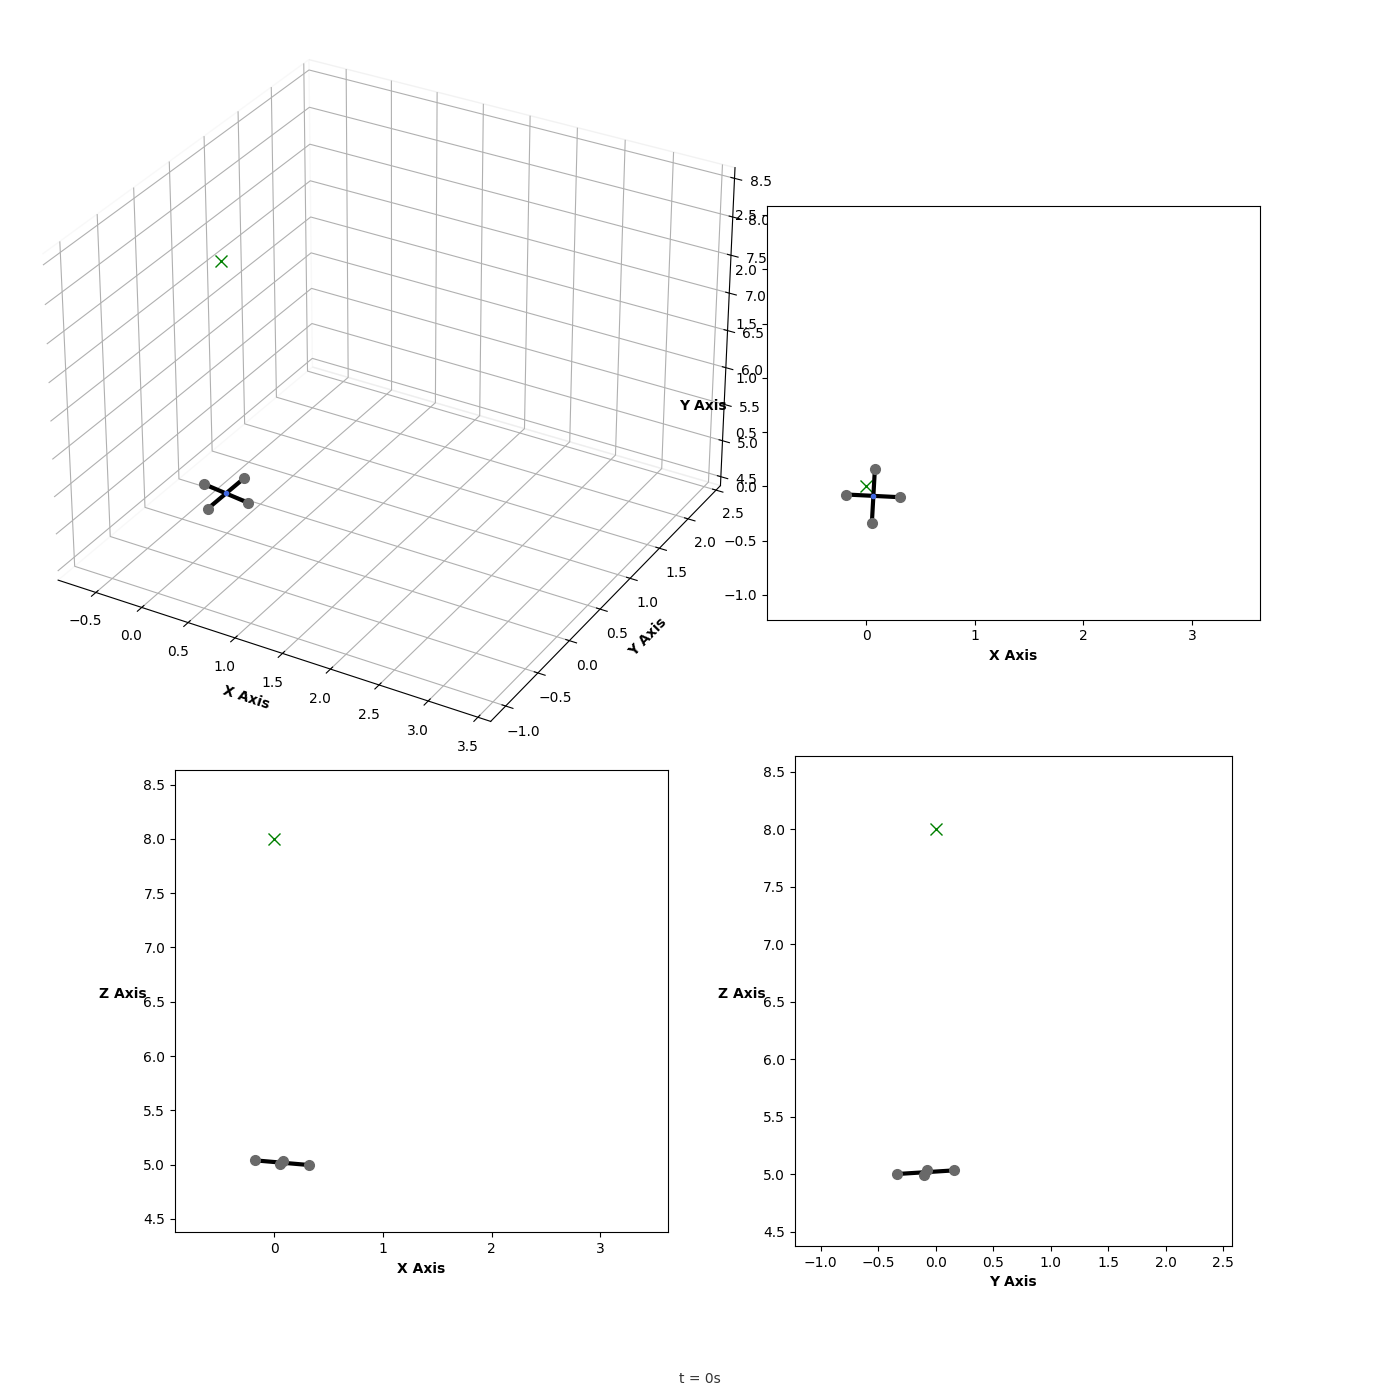

In [9]:
y0 = np.array([0, 0, 5] + 9*[0]) + 0.05*np.random.randn(12) # Initial state with small disturbances in all states
dt = 0.01 # seconds ... integration step for the simulation and animation
t_ref = 10 # seconds ... time to hold each reference
refs = np.array([[0, 0, 8], [3, 2, 5], [1, 1, 8]]) # References to follow in the simulation

# Simulation ... each reference is held for 10 seconds, taking 1000 samples in that interval
quadrotor_states = np.array([[] for _ in range(12)])
for ref in refs:
    states = solve_ivp_casadi(cl_quadrotor_fn, t_span=(0, t_ref), y0=y0 if quadrotor_states.size == 0 else quadrotor_states[:, -1],
                              N=int(t_ref/dt), u=ref)
    quadrotor_states = np.hstack([quadrotor_states, states.y])

%matplotlib ipympl
if 'quadrotor' in globals():
    plt.close('quadrotor')
fig = plt.figure('quadrotor', figsize=(14, 14))

# 4 subplots
axis_3d = fig.add_subplot(221, projection='3d')
axis_3d.set_position([0.0, 0.45, 0.55, 0.55])  # [left, bottom, width, height]
axis_xy = fig.add_subplot(222)  # top-down X-Y
axis_xz = fig.add_subplot(223)  # X-Z plane
axis_yz = fig.add_subplot(224)  # Y-Z plane

# Remove intenisty of grid lines in the 3D plot
axis_3d.xaxis.pane.fill = False
axis_3d.yaxis.pane.fill = False
axis_3d.zaxis.pane.fill = False

axis_3d.grid(True, color='gray', alpha=0.2, linewidth=0.5)

# Axis labels
axis_3d.set_xlabel('X Axis', fontweight='bold'); axis_3d.set_ylabel('Y Axis', fontweight='bold'); axis_3d.set_zlabel('Z Axis', fontweight='bold')
axis_xy.set_xlabel('X Axis', fontweight='bold'); axis_xy.set_ylabel('Y Axis', fontweight='bold', rotation=0, labelpad=15)
axis_xz.set_xlabel('X Axis', fontweight='bold'); axis_xz.set_ylabel('Z Axis', fontweight='bold', rotation=0, labelpad=15)
axis_yz.set_xlabel('Y Axis', fontweight='bold'); axis_yz.set_ylabel('Z Axis', fontweight='bold', rotation=0, labelpad=15)

# If crashes (z<0), stop the animation. If not, animate until the end of the simulation.
crash_point = np.where(quadrotor_states[2, :] < 0)[0][0] if np.any(quadrotor_states[2, :] < 0) else None
if crash_point:
    x_lims = (min(quadrotor_states[0, :crash_point+10]) - 1, max(quadrotor_states[0, :crash_point+10]) + 1)
    y_lims = (min(quadrotor_states[1, :crash_point+10]) - 1, max(quadrotor_states[1, :crash_point+10]) + 1)
    t_anim = quadrotor_states[crash_point+10]
    axis_xz.hlines(0, *x_lims, color='red', linestyle='--', linewidth=1)
    axis_yz.hlines(0, *y_lims, color='red', linestyle='--', linewidth=1)
else:
    t_anim = quadrotor_states.shape[1] * dt

anim, _ = AutoAnimation(fig, Quadrotor(fig, axis_3d, axis_xy, axis_xz, axis_yz, L=quadrotor_params['L'],
                                       xyz=quadrotor_states[0:3, :int(t_anim/dt)], angles=quadrotor_states[6:9, :int(t_anim/dt)],
                                       xyz_ref=np.repeat(refs.T, int(t_ref/dt), axis=1)[:, :int(t_anim/dt)]),
                    duration=t_anim, dt=dt, speed=10)

The same simulation can be done using numeric functions (i.e, without defining a new CasADi function):

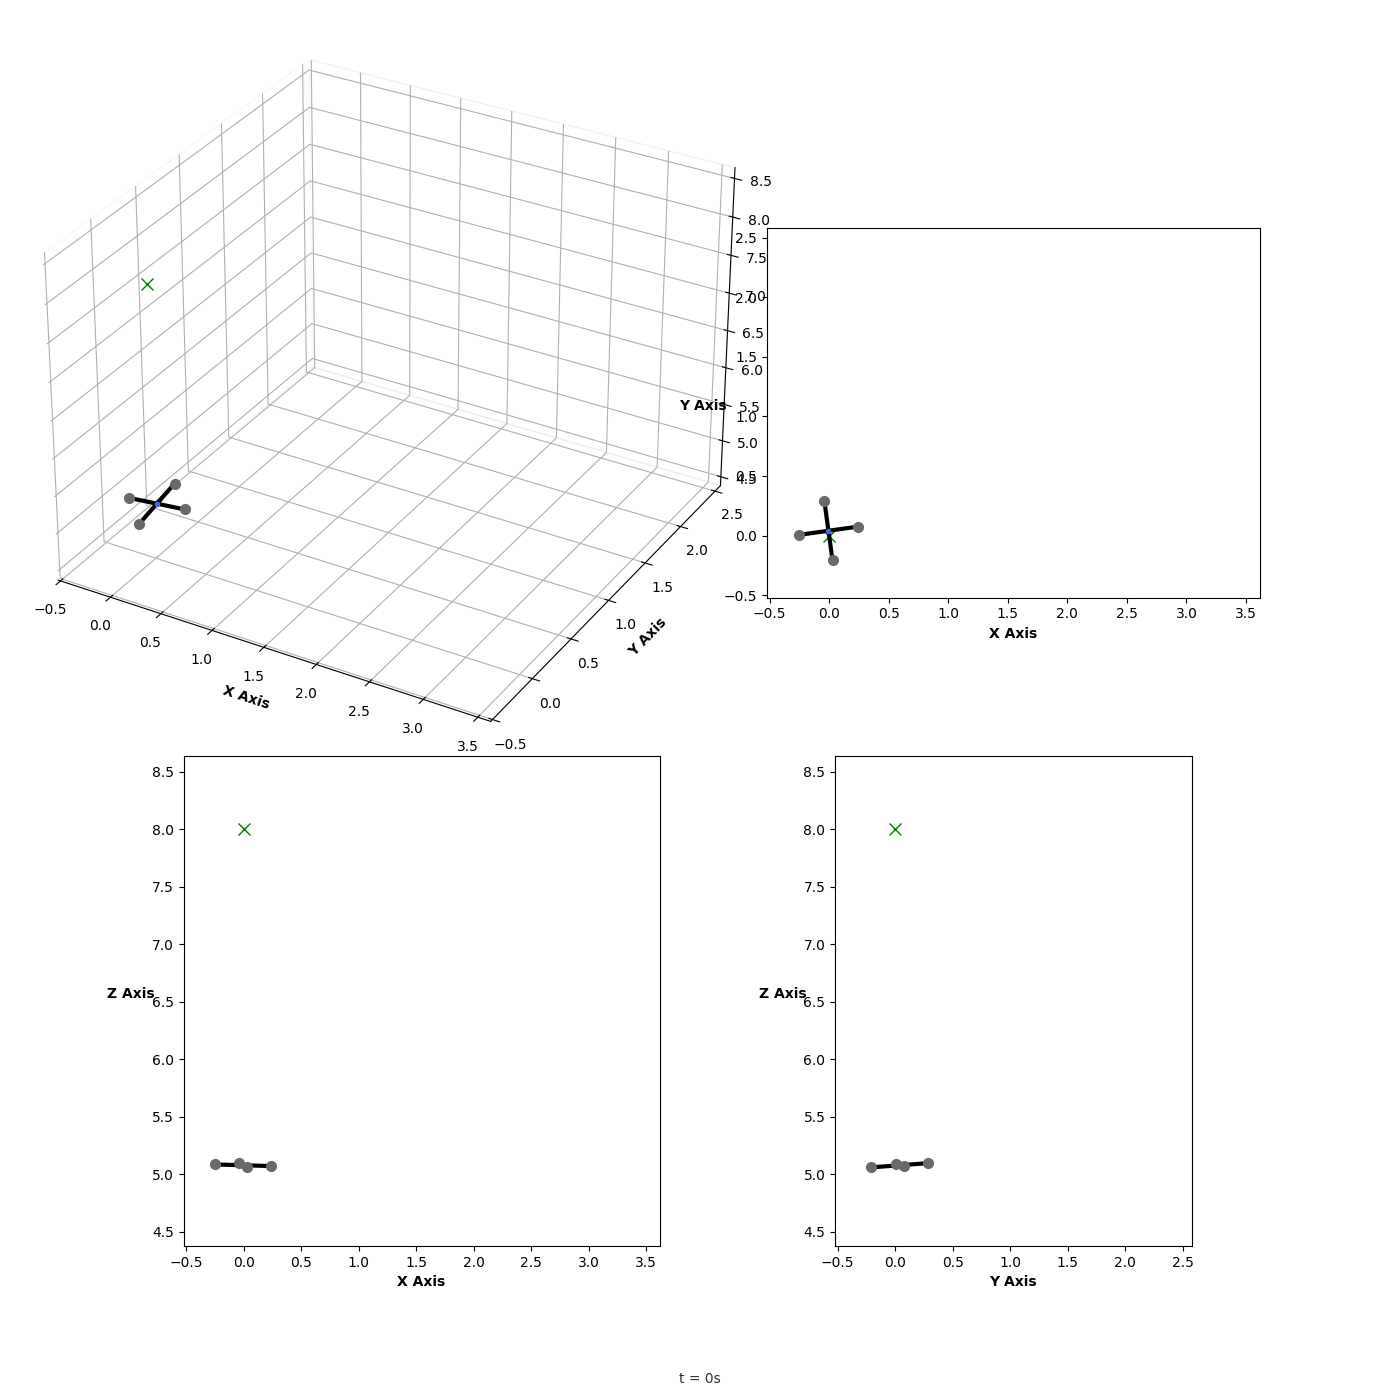

In [9]:
from benchmark_systems.models import quadrotor_ode as numeric_quadrotor
from scipy.integrate import solve_ivp

u_eq = np.array([w2, w2, w2, w2]) # Equilibrium input for the hover condition

def cl_numeric_quadrotor(t, x, xyz_ref, **params):
    x = x.reshape(-1, 1) # Convert to column vector
    x_ref = np.hstack([xyz_ref, np.zeros(9)]).reshape(-1, 1) # Convert to column vector
    du = -K @ (x - x_ref)
    return numeric_quadrotor(t, x.flatten(), u=u_eq + du.flatten(), **params)

# Simulation
quadrotor_states = np.array([[] for _ in range(12)])
for ref in refs:
    states = solve_ivp(lambda t, x: cl_numeric_quadrotor(t, x, ref, **quadrotor_params),
                          y0=y0 if quadrotor_states.size == 0 else quadrotor_states[:, -1],
                          t_span=(0, t_ref), t_eval=np.linspace(0, t_ref, int(t_ref/dt)), rtol=1e-6)
    quadrotor_states = np.hstack([quadrotor_states, states.y])

%matplotlib ipympl
if 'quadrotor_numeric' in globals():
    plt.close('quadrotor_numeric')
fig = plt.figure('quadrotor_numeric', figsize=(14, 14))

# 4 subplots
axis_3d = fig.add_subplot(221, projection='3d')
axis_3d.set_position([0.0, 0.45, 0.55, 0.55])  # [left, bottom, width, height]
axis_xy = fig.add_subplot(222)  # top-down X-Y
axis_xz = fig.add_subplot(223)  # X-Z plane
axis_yz = fig.add_subplot(224)  # Y-Z plane

# Remove intenisty of grid lines in the 3D plot
axis_3d.xaxis.pane.fill = False
axis_3d.yaxis.pane.fill = False
axis_3d.zaxis.pane.fill = False

axis_3d.grid(True, color='gray', alpha=0.2, linewidth=0.5)

# Axis labels
axis_3d.set_xlabel('X Axis', fontweight='bold'); axis_3d.set_ylabel('Y Axis', fontweight='bold'); axis_3d.set_zlabel('Z Axis', fontweight='bold')
axis_xy.set_xlabel('X Axis', fontweight='bold'); axis_xy.set_ylabel('Y Axis', fontweight='bold', rotation=0, labelpad=15)
axis_xz.set_xlabel('X Axis', fontweight='bold'); axis_xz.set_ylabel('Z Axis', fontweight='bold', rotation=0, labelpad=15)
axis_yz.set_xlabel('Y Axis', fontweight='bold'); axis_yz.set_ylabel('Z Axis', fontweight='bold', rotation=0, labelpad=15)

# If crashes (z<0), stop the animation. If not, animate until the end of the simulation.
crash_point = np.where(quadrotor_states[2, :] < 0)[0][0] if np.any(quadrotor_states[2, :] < 0) else None
if crash_point:
    x_lims = (min(quadrotor_states[0, :crash_point+10]) - 1, max(quadrotor_states[0, :crash_point+10]) + 1)
    y_lims = (min(quadrotor_states[1, :crash_point+10]) - 1, max(quadrotor_states[1, :crash_point+10]) + 1)
    t_anim = quadrotor_states[crash_point+10]
    axis_xz.hlines(0, *x_lims, color='red', linestyle='--', linewidth=1)
    axis_yz.hlines(0, *y_lims, color='red', linestyle='--', linewidth=1)
else:
    t_anim = quadrotor_states.shape[1] * dt

anim, _ = AutoAnimation(fig, Quadrotor(fig, axis_3d, axis_xy, axis_xz, axis_yz, L=quadrotor_params['L'],
                                       xyz=quadrotor_states[0:3, :int(t_anim/dt)], angles=quadrotor_states[6:9, :int(t_anim/dt)],
                                       xyz_ref=np.repeat(refs.T, int(t_ref/dt), axis=1)[:, :int(t_anim/dt)]),
                    duration=t_anim, dt=dt, speed=10)

### Oil well

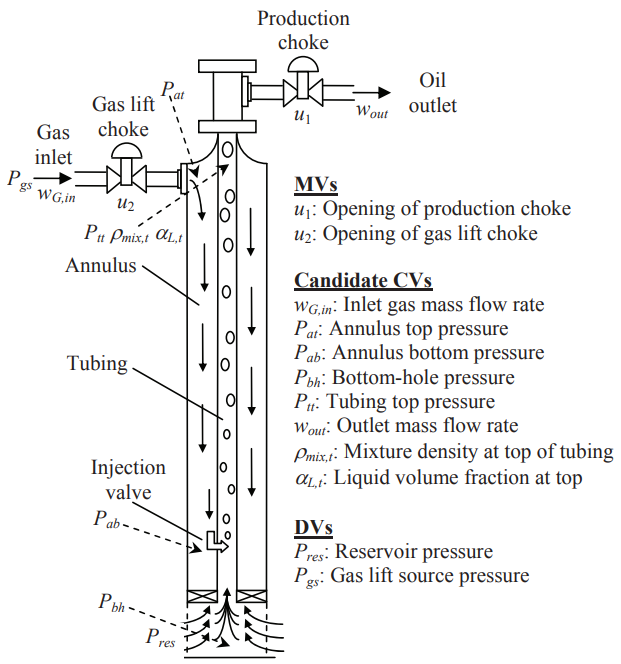

###### Image source: https://doi.org/10.3182/20120710-4-SG-2026.00110

States: $x = \begin{bmatrix} x_0 \\ x_1 \\ x_2 \end{bmatrix}$; Control actions: $u = \begin{bmatrix} u_1 \\ u_2 \end{bmatrix}$;
Algebraic states: $z = \begin{bmatrix} w_{G_in} \ P_{at} \ P_{ab} \ P_{bh} \ P_{tt} \ w_{out} \ \rho_{mix,t} \ \alpha_{L,t} \end{bmatrix}^T$

$x_0$ is the mass of gas in the annulus, $x_1$ is the mass of gas in the tubing, and $x_2$ is the mass of liquid in the tubing.

In [6]:
annulus_params = {
    'T_a': 348, # K
    'V_a': 64.34, # m^3
    'L_a': 2048, # m
    'K_gs': 9.98e-5,
    'K_inj': 1.4e-4,
}
gas_params = {
    'M_G': 16.7, # kg/mol
    'P_gs': 140, # bars
}
tubing_params = {
    'T_t': 350, # K
    'D_t': 0.124, # m
    'L_t': 1500, # m
    'V_t': 25.03, # m^3
    'epsilon': 2.8e-5, # m
    'K_pr': 2.9e-3,
    'P_out': 20, # bars
}
bottom_hole_params = {
    'S_bh': 0.0314, # m^2
    'L_bh': 75, # m
}
reservoir_params = {
    'P_res': 160, # bars
    'avg_w_res': 18, # kg/s
    'PI': 2.47e-6, # kg/s/Pa
    'GOR': 0,
}
oil_params = {
    'mu': 3.64e-3, # Pa.s
    'rho_L': 760, # kg/m^3
}

In [7]:
u_well = [0.5, 0.4] # Initial control actions ... [0.3, 0.4] stable, [0.5, 0.4] unstable
initial_guess = [
    3232, # mass of gas in the annulus ... if u0 = [0.3, 0.4], 3232 corresponds to the equilibrium
    269, # mass of gas in the tubing ... for u0 = [0.3, 0.4], 269 corresponds to the equilibrium
    10275, # mass of liquid in the tubing ... for u0 = [0.3, 0.4], 10275 corresponds to the equilibrium
]
simulation_time = 15*3600 # seconds

In [ ]:
oil_well_states = solve_dae(lambda t, x, x_dot: oil_well(t, x, x_dot, **annulus_params, **gas_params, **tubing_params, **bottom_hole_params, **reservoir_params, **oil_params, u=u_well),
                            t_span=(0, simulation_time), y0=initial_guess + [0]*8, yp0=np.zeros(11), t_eval=np.linspace(0, simulation_time, simulation_time), rtol=1e-6)

# First sample is the initial guess. We remove it.
t = oil_well_states.t[:-1]/3600 # hours
x_0, x_1, x_2, w_G_in, P_at, P_ab, P_bh, P_tt, w_out, rho_m_tt, alpha_L_tt = [state[1:] for state in oil_well_states.y]

%matplotlib ipympl
if 'oil_well' in globals():
    plt.close('oil_well')
fig, axis = plt.figure('oil_well'), plt.gca()
anim, _ = AutoAnimation(fig, OilWell(axis, x0=x_0, x1=x_1, x2=x_2, P_tt=P_tt, w_out=w_out,
                                     u1=np.repeat(u_well[0], len(t)), u2=np.repeat(u_well[1], len(t)),
                                     w_G_in=w_G_in, P_ab=P_ab, P_bh=P_bh, P_at=P_at,
                                     rho_m=rho_m_tt, alpha_L=alpha_L_tt),
                        duration=simulation_time, dt=1, fps=30)

### pH Neutralization Process

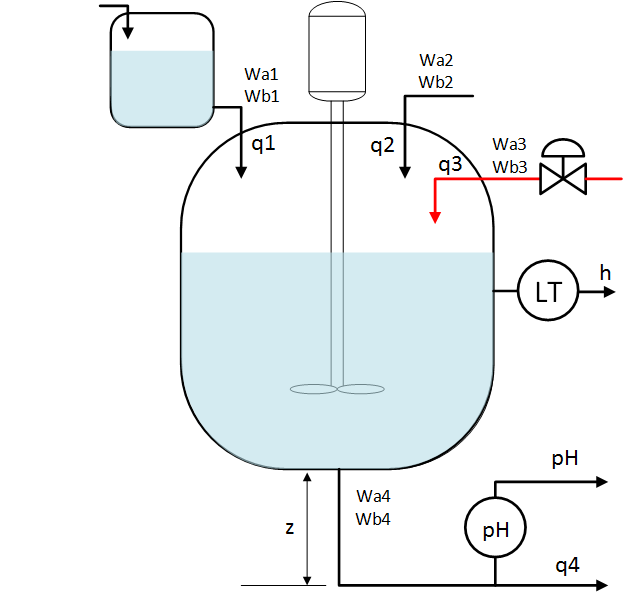

States: $x = \begin{bmatrix} W_{a4} \\ W_{b4} \\ h \\ pH \end{bmatrix}$; Control actions: $u = q_3$

In [3]:
reactor_params = {
    'A': 207, # cm^2
    'z': 11.5, # cm
}

buffer_tank_params = {
    'Cv4': 4.59,
    'n': 0.607,
}

# Reaction invariant concentrations
acid_inflow = { # Adds only H+ to the invariant concentrations.
    'Wa1': 3e-3, # mol/L
    'Wb1': 0, # mol/L
}
buffer_inflow = { # Reduces H+ and increases weak acid concentration
    'Wa2': -0.03, # mol/L
    'Wb2': 0.03, # mol/L
}
base_inflow = { # Reduces H+ and weak acid concentrations
    'Wa3': -3.05e-3, # mol/L
    'Wb3': -5e-5, # mol/L
}

dissociation_constants = {
    'pK1': 6.35, # 1st dissociation constant of H2CO3
    'pK2': 10.33, # 2nd dissociation constant of H2CO3
}

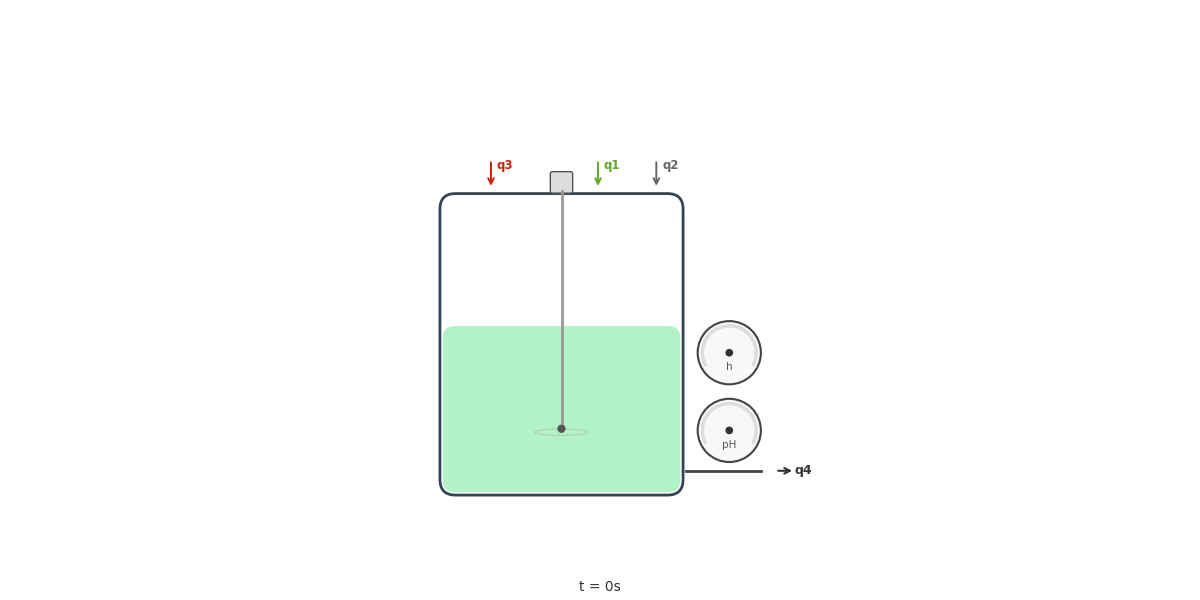

In [ ]:
duration = 4020 # seconds
step_duration = 60 # seconds
Ts = 1 # seconds

# Inlet flows
rangen = np.random.default_rng(seed=44)
k = np.arange(0, duration, step_duration)
q1 = 16.6 # cm^3/s
q2 = 0.55 # cm^3/s
q3 = np.full(len(k), 15.6) # cm^3/s
q3[10:] += rangen.uniform(-1, 1, len(k)-10) # cm^3/s

# Simulation of the neutralization process ... Every setpoint is held for 30 seconds
ph_states = np.array([[] for _ in range(4)])
ph_states_dot = np.array([[] for _ in range(4)])
for u_k in q3:
    # Solve the system keeping u_k for 30 seconds, taking a sample every second
    states = solve_dae(lambda t, x, x_dot: neutralization(t, x, x_dot, **reactor_params, **buffer_tank_params, **acid_inflow, **buffer_inflow, **base_inflow, **dissociation_constants,
                                                         q1 = q1, d = q2, u = u_k),
                       y0 = [-4.32e-4, 5.28e-4, 14, 7] if ph_states.size == 0 else ph_states[:, -1],
                       yp0 = np.zeros(4) if ph_states_dot.size == 0 else ph_states_dot[:, -1],
                       t_span=(0, step_duration), t_eval=np.linspace(Ts, step_duration, int(step_duration/Ts)), rtol=1e-6)
    # Append the states
    ph_states = np.hstack([ph_states, states.y])
    ph_states_dot = np.hstack([ph_states_dot, states.yp])

%matplotlib ipympl
if 'ph_neutralization' in globals():
    plt.close('ph_neutralization')
fig, axis = plt.figure('ph_neutralization'), plt.gca()
anim, _ = AutoAnimation(fig, pHNeutralization(axis, h=ph_states[2], pH=ph_states[3], q1=np.repeat(q1, ph_states.shape[1]), q2=np.repeat(q2, ph_states.shape[1]), q3=np.repeat(q3, int(step_duration/Ts))),
                        duration=duration, dt=Ts, fps=90)